# Regressione
In questo notebook proviamo a prevedere l'andamento dell'ozono, dei pm10 e dei pm2.5 in base ai giorni precedenti tramite regressione ad una funzione data.\
In particolare, dopo aver fatto la regressione di una funzione ai nostri dati di train, proviamo a vedere come questa si comporta nel prevedere i dati di test.

Si seguono le considerazioni sulle time series sviluppate nei notebook precedenti.

In [159]:
# importiamo i pacchetti necessari
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression, ElasticNet

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.reg_funcs as fs

from IPython.display import Image, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [160]:
# scelta del seed random per la riproducibilità dei risultati
seed = 0

Non potendo visualizzare i nostri dati nello spazio delle coppie (X, y) non possiamo a priori sapere quale sarà la funzione che meglio descriverà i nostri dati. Per tale motivo scegliamo innanzitutto di provare a fittare un modello lineare e vedere come questo si comporta. Successivamente proveremo ad allenare modelli più complessi e confronteremo i risultati

# Regressione lineare
In classe e nel corso delle esercitazioni abbiamo visto la teoria della regressione. Qui utilizziamo due principali regressori implementati da Sickit Learn:
* LinearRegressionCV: modello particolarmente semplice e senza regolarizzazione, che implementa semplicemente i minimi quadrati;
* ElasticNetCV: modello che implementa una regressione lineare con regolarizzazione mista tra Ridge e Lasso

Costruiamo dei dataframe per la regressione in modo da massimizzare il numero di punti a nostra disposizione

## PM10

### Importiamo il dataframe

In [161]:
# Importiamo il dataframe costruito separatamente
hour_PM10_df = pd.read_csv('../../data/processed/dataset_hour_PM10_processed.csv')

# droppiamo la feature Riva del Garda, che tanto non ha dati associati
hour_PM10_df.drop(columns='station_Riva del Garda', inplace=True)

hour_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,sin_week_day,...,precipitation,PM10_1,PM10_2,PM10_3,PM10_diff_1,PM10_diff_2,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,21.0,20.0,19.0,1.0,2.0,18.0,16.969367,14.669913,19.0
1,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,19.0,21.0,20.0,-2.0,-1.0,16.0,15.329278,16.969367,24.0
2,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,24.0,19.0,21.0,5.0,3.0,16.0,17.519438,15.329278,19.0
3,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,19.0,24.0,19.0,-5.0,0.0,15.0,17.446178,17.519438,22.0
4,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,0.0,22.0,19.0,24.0,3.0,-2.0,15.0,17.484408,17.446178,26.0


### LinearRegression

#### Pipeline

In [162]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM10_df.columns if col.startswith('station_')]
num_features = hour_PM10_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_reg = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

# modello base che vogliamo usare
lin_reg = LinearRegression(n_jobs = -1)

# pipeline
model_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', lin_reg)
])

#### Divisione in Train, Test + fit al modello
Visto che non abbiamo iperparametri da validare non introduciamo valisd

In [163]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
hO3_X_train, hO3_X_valid, hO3_X_test, hO3_y_train, hO3_y_valid, hO3_y_test = fs.get_train_valid_test(hour_PM10_df, 0.8, 0.0, feature_cols)

In [164]:
model_reg.fit(hO3_X_train, hO3_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

#### Quali sono le features più importanti?

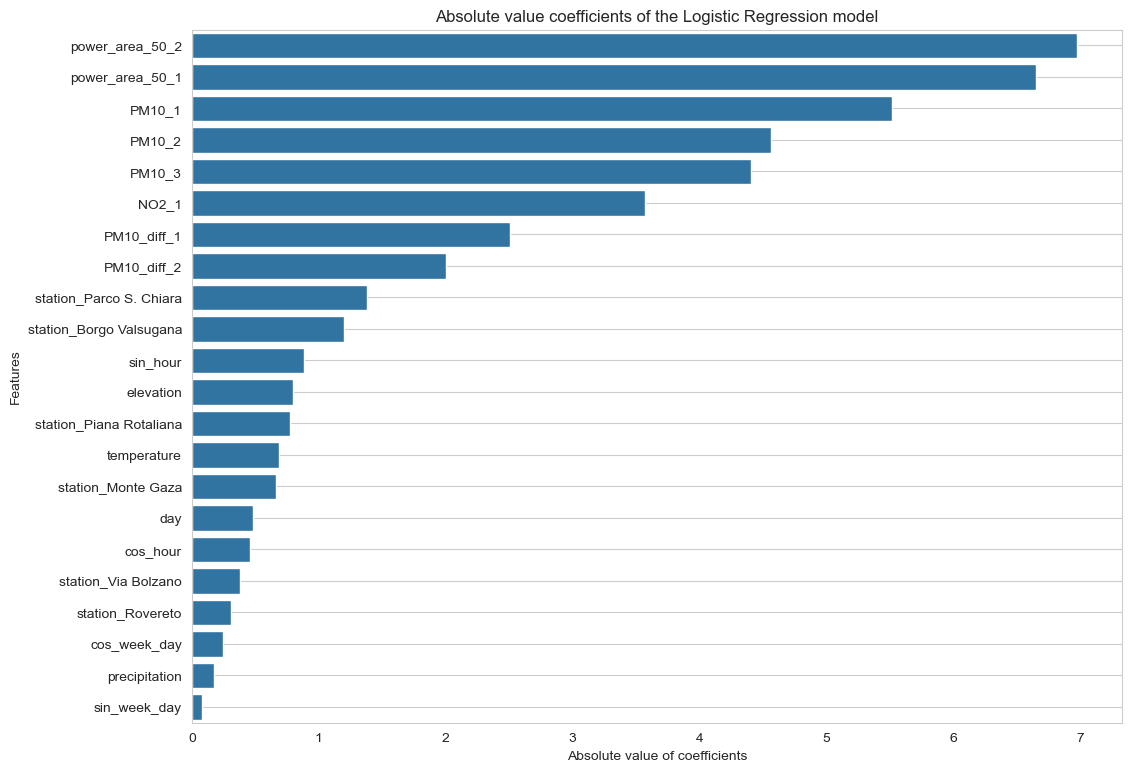

In [165]:
fs.display_abs_coefs(model_reg.named_steps['regressor'], feature_cols)

#### Performance del modello
Cominciamo studiando quanto bene il modello fitti i dati del train

In [166]:
# studiamo R^2 e mean square error
fs.get_reg_error(model_reg, hO3_X_train, hO3_y_train, 'Train')

Train: R^2 = 0.8630480021917476, MSE = 43.00751555572841


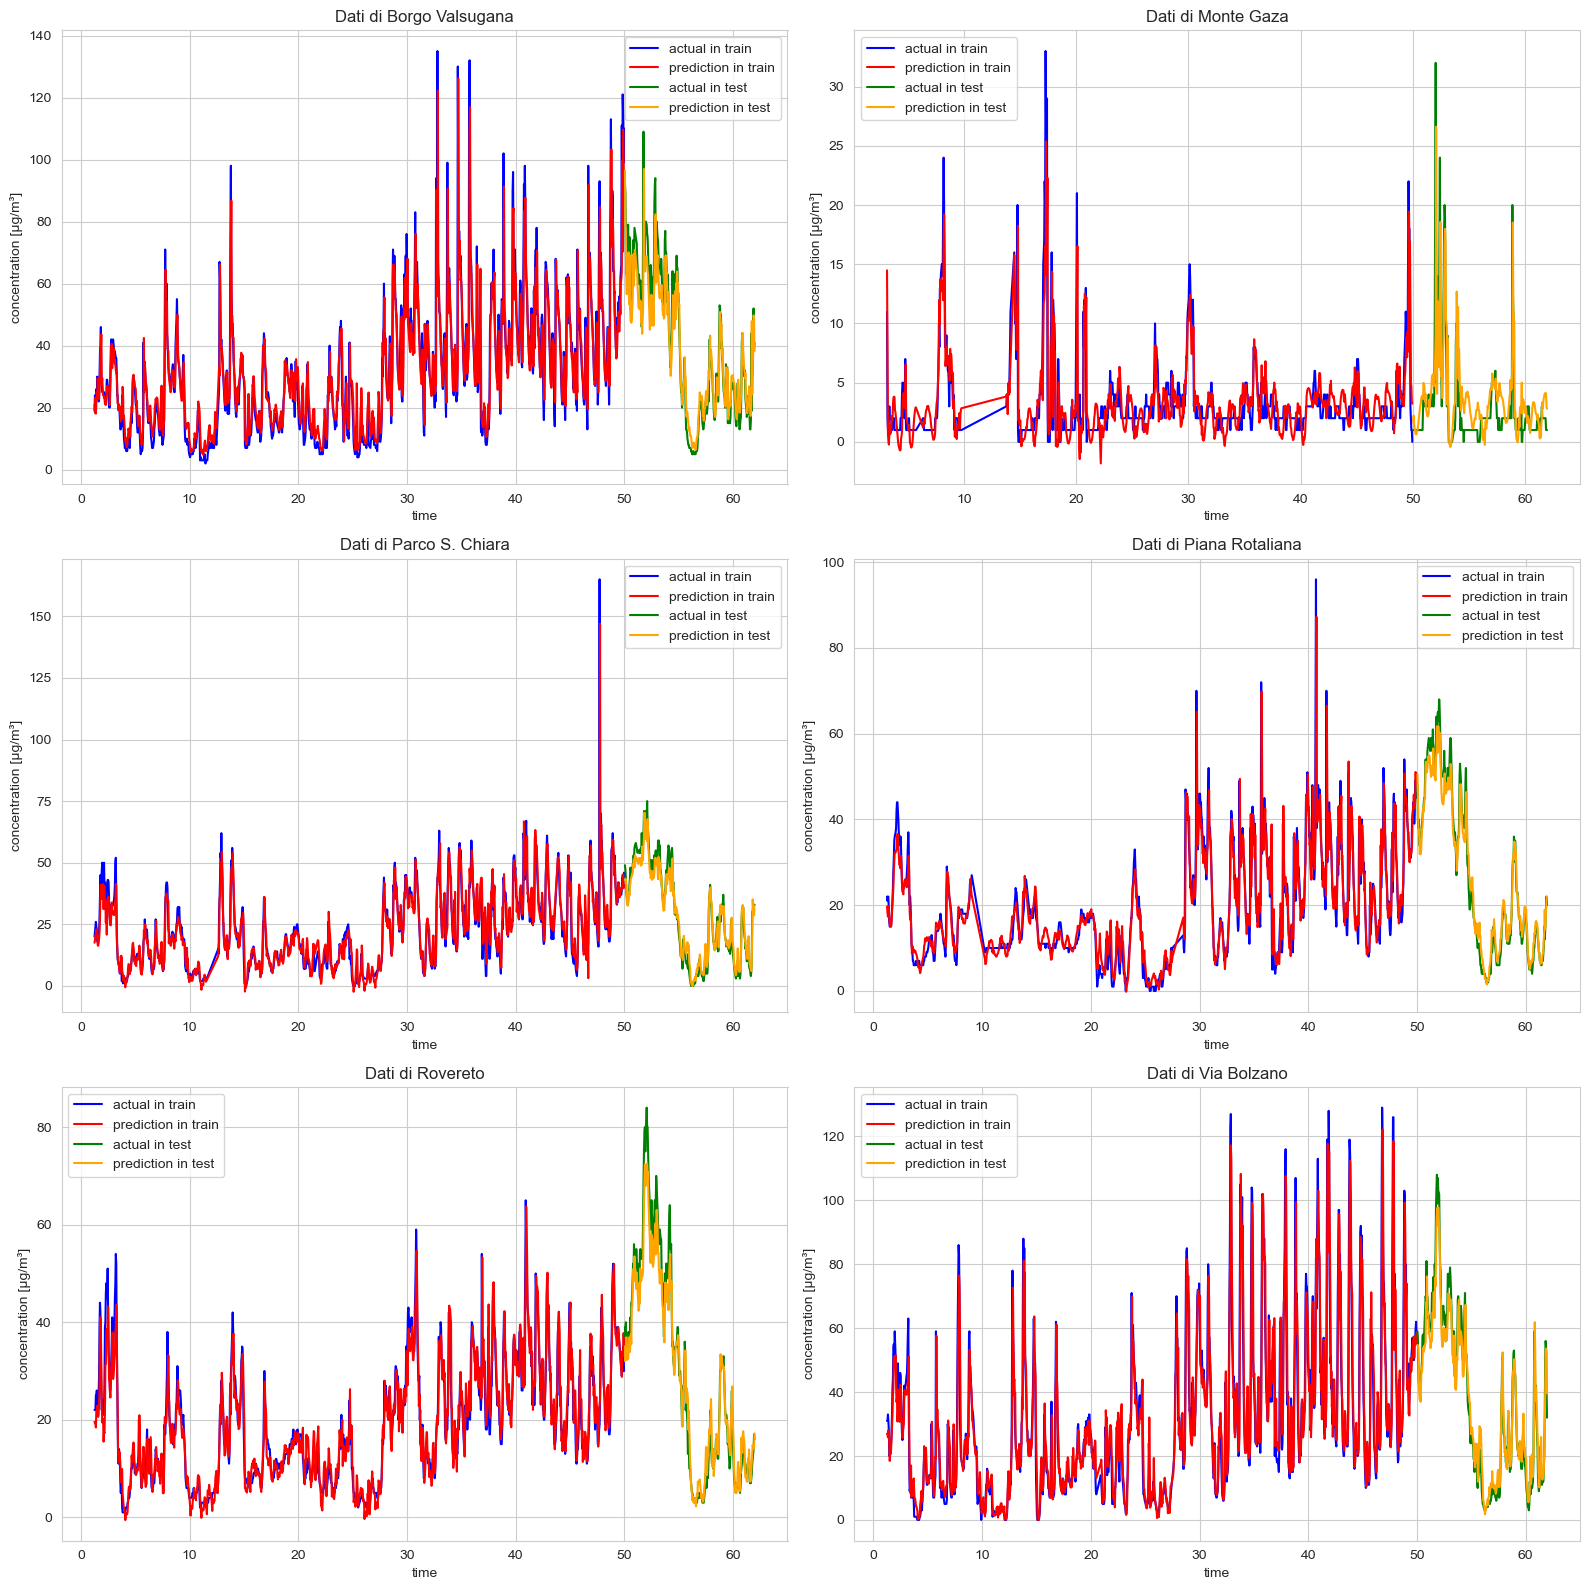

In [167]:
# proviamo a studiare graficamente la performance del regressore, creando dei grafici con il valore di PM10 sulle ordinate ed il tempo sulle ascisse
fs.plot_predictions(model_reg, hO3_X_train, hO3_y_train, hO3_X_test, hO3_y_test)

Sembra fittare abbastanza bene. Proviamo a vedere cosa succede se guardiamo il test

Sembra lavorare bene per tutte eccetto che per Monte Gaza. Probabilmente il problema sono tutte quelle misurazioni "flat" di questa stazione. Secondo me ha delle rilevazioni non fisiche

Proviamo a vedere se usando ElasticNet la situazione migliora

### ElasticNet
#### Pipeline

In [168]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM10_df.columns if col.startswith('station_')]
num_features = hour_PM10_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_reg = ColumnTransformer([('num', StandardScaler(), num_features),('one-hot', 'passthrough', non_num_features)])

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

# pipeline
model_en = Pipeline(steps=[('preprocessor', preprocessor_reg),('regressor', ElasticNet(random_state=seed, max_iter=20000, tol=1e-3))])

# griglia degli iperparametri
param_grid_en = {
    'regressor__alpha': np.logspace(-2, 2, 50),                     # valori di alpha per il regolarizzatore
    'regressor__l1_ratio': [0.1, 0.25, 0.5, 0.75, 1.0],             # rateo l1/l2
    'regressor__fit_intercept': [True, False],                      # sceglie se mettere l'intercetta o no
    'regressor__selection': ['cyclic', 'random'],                   # sceglie il modo in aggiornare le features
}

# ricerca degli iperparametri
gridsrc_en = GridSearchCV(estimator=model_en,                                        # usiamo la pipeline
                         param_grid=param_grid_en,                                  # cerchiamo gli iperparametri migliori
                         scoring='neg_root_mean_squared_error',                     # metro di ottimizzazione
                         cv=tscv,                                                   # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                         n_jobs=-1,                                                 # usiamo la massima potenza disponibile nella CPU
                         refit=True)                                                # vogliamo poi allenare il modello con i migliori iperparametri

#### Train, Test split + fit
Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [169]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
hO3_X_train, hO3_X_valid, hO3_X_test, hO3_y_train, hO3_y_valid, hO3_y_test = fs.get_train_valid_test(hour_PM10_df, 0.8, 0.0, feature_cols)

In [170]:
# training
gridsrc_en.fit(hO3_X_train, hO3_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': array([1.0000...00000000e+02]), 'regressor__fit_intercept': [True, False], 'regressor__l1_ratio': [0.1, 0.25, ...], 'regressor__selection': ['cyclic', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose:

In [171]:
best_model = gridsrc_en.best_estimator_

Train: R^2 = 0.8228537377662531, MSE = 48.119789387470895


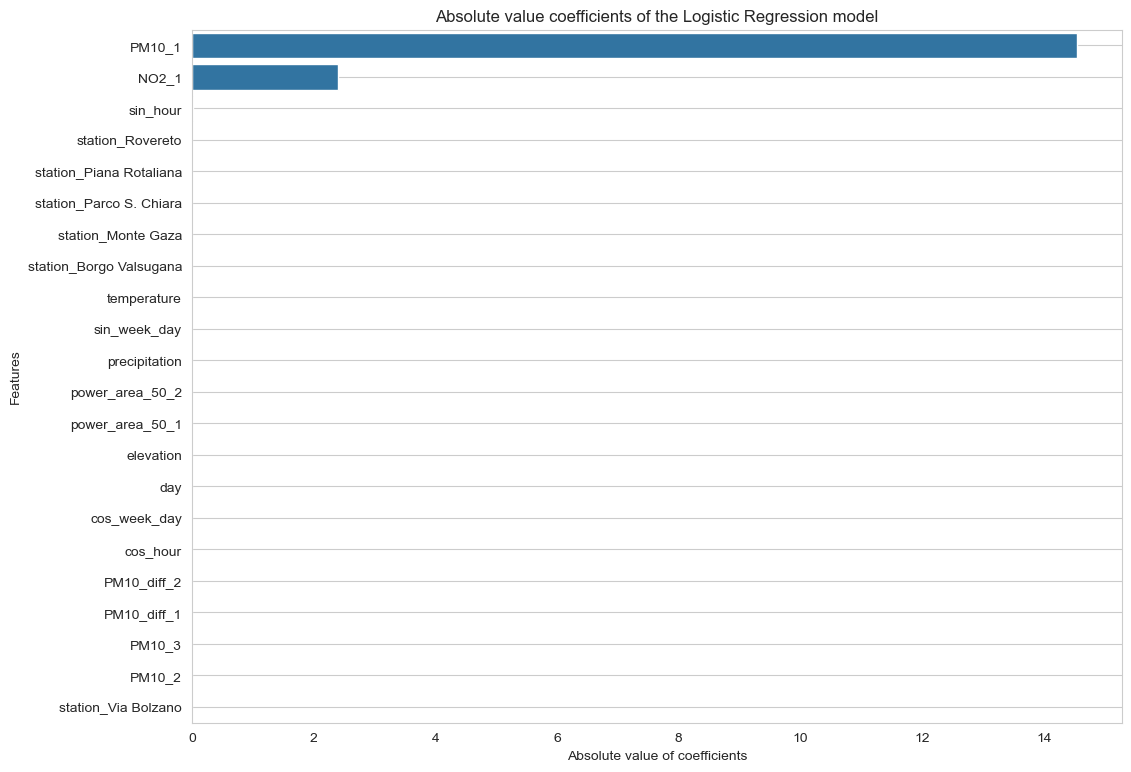

In [172]:
fs.display_abs_coefs(best_model.named_steps['regressor'], feature_cols)

# studiamo R^2 e mean square error
fs.get_reg_error(best_model, hO3_X_train, hO3_y_train, 'Train')

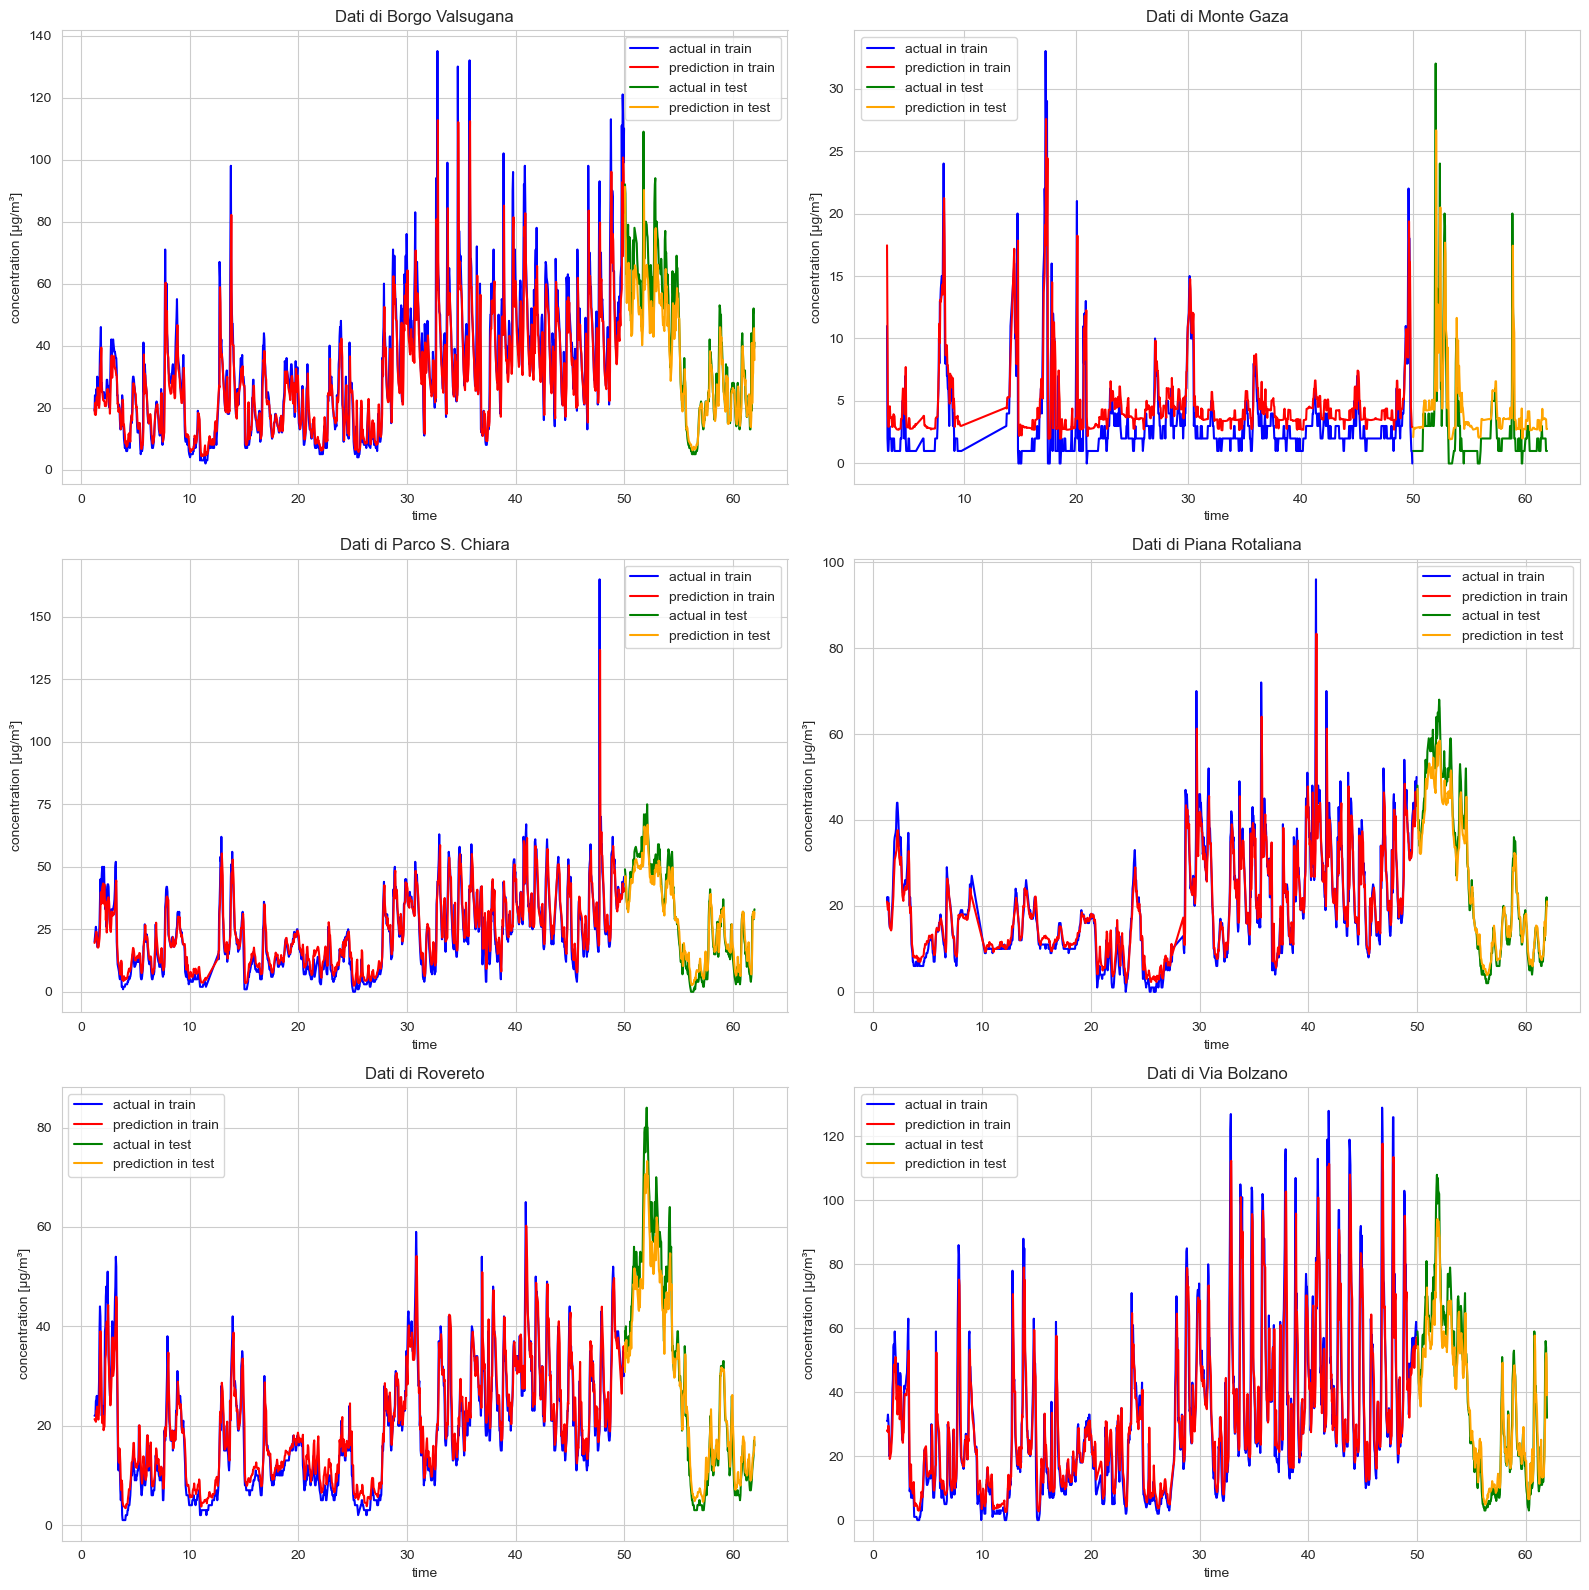

In [173]:
fs.plot_predictions(best_model, hO3_X_train, hO3_y_train, hO3_X_test, hO3_y_test)

Sembra che l'ElasticNet faccia peggio del semplice regressore lineare. BOOOH

In [174]:
hour_PM2_5_df = pd.read_csv('../../data/processed/dataset_hour_PM2_5_processed.csv')
hour_PM2_5_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,precipitation,PM2.5_1,PM2.5_2,PM2.5_3,PM2.5_diff_1,PM2.5_diff_2,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,13.0,11.0,12.0,2.0,1.0,18.0,16.969367,14.669913,13.0
1,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,13.0,13.0,11.0,0.0,2.0,16.0,15.329278,16.969367,16.0
2,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,16.0,13.0,13.0,3.0,3.0,16.0,17.519438,15.329278,11.0
3,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,11.0,16.0,13.0,-5.0,-2.0,15.0,17.446178,17.519438,12.0
4,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,12.0,11.0,16.0,1.0,-4.0,15.0,17.484408,17.446178,14.0


Uso le stesse pipeline viste in precedenza

In [175]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in hour_PM2_5_df.columns if col.startswith('station_')]
num_features = hour_PM2_5_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_reg = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('one-hot', 'passthrough', non_num_features)
])

# cross validation per time series
tscv = TimeSeriesSplit(n_splits=5)

# modello base che vogliamo usare
lin_reg = LinearRegression(n_jobs = -1)

# pipeline
model_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regressor', lin_reg)
])

In [176]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
hPM2_5_X_train, hPM2_5_X_valid, hPM2_5_X_test, hPM2_5_y_train, hPM2_5_y_valid, hPM2_5_y_test = fs.get_train_valid_test(hour_PM2_5_df, 0.8, 0.0, feature_cols)

In [177]:
model_reg.fit(hPM2_5_X_train, hPM2_5_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

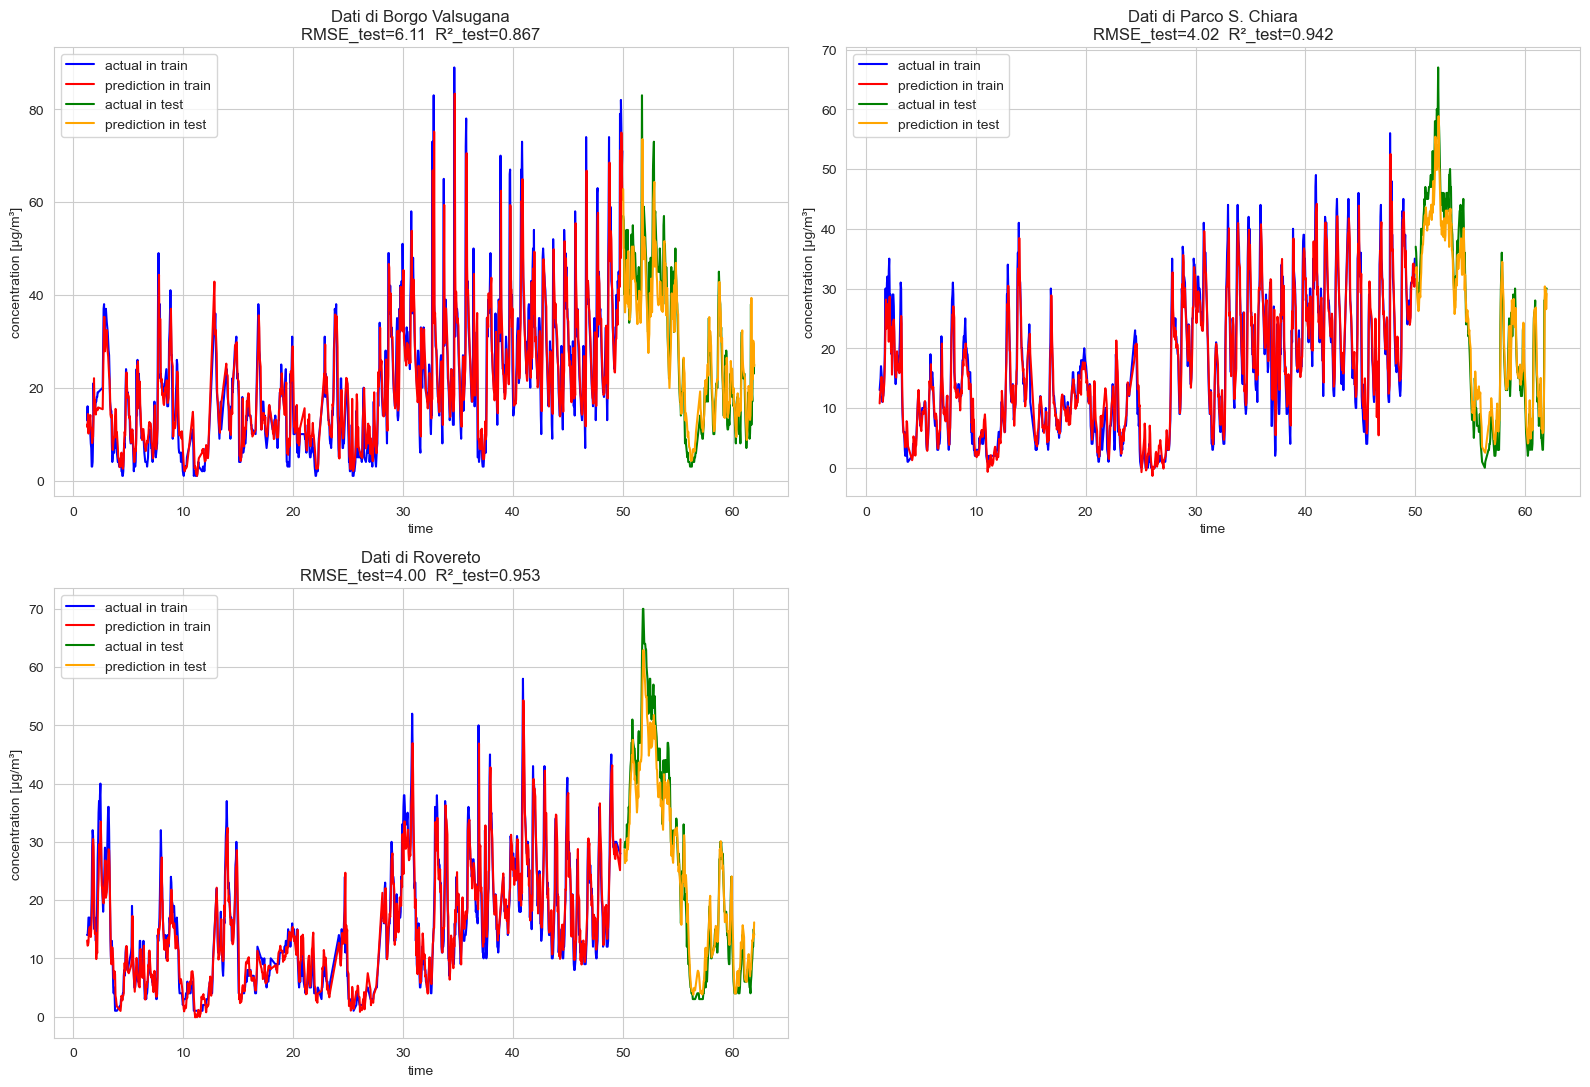

In [180]:
# proviamo a studiare graficamente la performance del regressore, creando dei grafici con il valore di PM10 sulle ordinate ed il tempo sulle ascisse
fs.plot_predictions(model_reg, hPM2_5_X_train, hPM2_5_y_train, hPM2_5_X_test, hPM2_5_y_test)

In [179]:
hour_O3_df = pd.read_csv('../../data/processed/dataset_hour_O3_processed.csv')
hour_O3_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,O3_1,O3_2,O3_3,O3_diff_1,O3_diff_2,PM10_1,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,2.0,2.0,2.0,0.0,0.0,21.0,18.0,16.969367,14.669913,2.0
1,1,0,0,0,0,0,0,410,1,-0.900969,...,2.0,2.0,2.0,0.0,0.0,19.0,16.0,15.329278,16.969367,2.0
2,1,0,0,0,0,0,0,410,1,-0.900969,...,2.0,2.0,2.0,0.0,0.0,24.0,16.0,17.519438,15.329278,2.0
3,1,0,0,0,0,0,0,410,1,-0.900969,...,2.0,2.0,2.0,0.0,0.0,19.0,15.0,17.446178,17.519438,3.0
4,1,0,0,0,0,0,0,410,1,-0.900969,...,3.0,2.0,2.0,1.0,1.0,22.0,15.0,17.484408,17.446178,5.0
